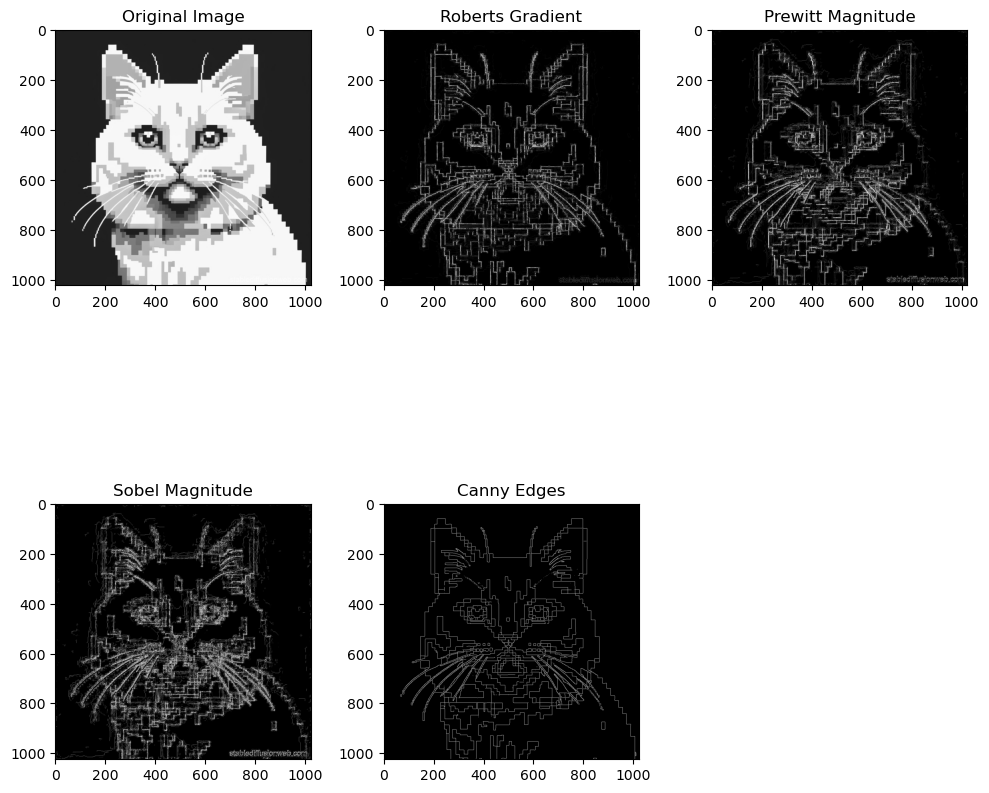

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img=cv2.imread('imagen1.jpg')
gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
robertx=np.array([[1,0], [0,-1]])
roberty=np.array([[0,1], [-1,0]])
robx_img=cv2.filter2D(gray, -1, robertx)
roby_img=cv2.filter2D(gray, -1, roberty)
rob_grad= np.sqrt(robx_img**2 + roby_img**2)
rob_grad_dir=np.arctan2(roby_img, robx_img) 

#prewit
prewit_x=np.array([[-1,0,1], [-1,0,1], [-1,0,1]])
prewit_y=np.array([[-1,-1,-1], [0,0,0], [1,1,1]])
prex_img=cv2.filter2D(gray, -1, prewit_x)
prey_img=cv2.filter2D(gray, -1, prewit_y)
prewitt_mag=np.sqrt(prex_img**1 + prey_img**2)
prewitt_dir=np.arctan2(prey_img, prex_img)

# sobel
sobel_x=np.array([[-1,0,1], [-2,0,2], [-1,0,1]])
sobel_y=np.array([[-1,-2,-1], [0,0,0], [1,2,1]])
sobx_img=cv2.filter2D(gray, -1, sobel_x)
soby_img=cv2.filter2D(gray, -1, sobel_y)
sobel_mag=np.sqrt(sobx_img**2 + soby_img**2)
sobel_dir=np.arctan2(soby_img, sobx_img)

cany_img=cv2.Canny(gray,100,100)

plt.figure(figsize=(10,10))
plt.subplot(2,3,1),plt.imshow(gray,cmap='gray'),plt.title('Original Image')
plt.subplot(2,3,2),plt.imshow(rob_grad,cmap='gray'),plt.title('Roberts Gradient')
plt.subplot(2,3,3),plt.imshow(prewitt_mag,cmap='gray'),plt.title('Prewitt Magnitude')
plt.subplot(2,3,4),plt.imshow(sobel_mag,cmap='gray'),plt.title('Sobel Magnitude')
plt.subplot(2,3,5),plt.imshow(cany_img,cmap='gray'),plt.title('Canny Edges')
plt.tight_layout()
plt.show()




SOBEL

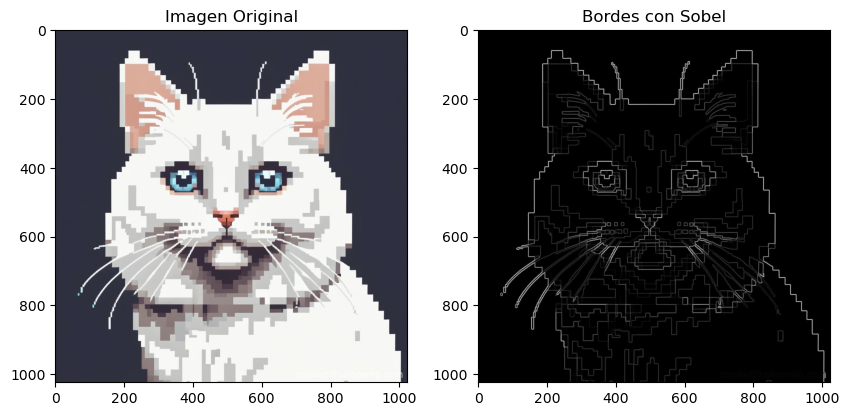

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_sobel(img):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    g_x=cv2.Sobel(img_gris, cv2.CV_64F, 1, 0, ksize=3)
    g_y=cv2.Sobel(img_gris, cv2.CV_64F, 0, 1, ksize=3)
    
    mag=np.sqrt(np.square(g_x) + np.square(g_y))
    mag=cv2.normalize(mag, None,0,255,cv2.NORM_MINMAX,cv2.CV_8U)
    return mag

#mostrar imagen
img=cv2.imread('imagen1.jpg')
sobel_result=filtro_sobel(img)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.title('Imagen Original')

plt.subplot(1,2,2)
plt.imshow(sobel_result,cmap='gray')
plt.title('Bordes con Sobel')
plt.show()


Sobel Mejorado

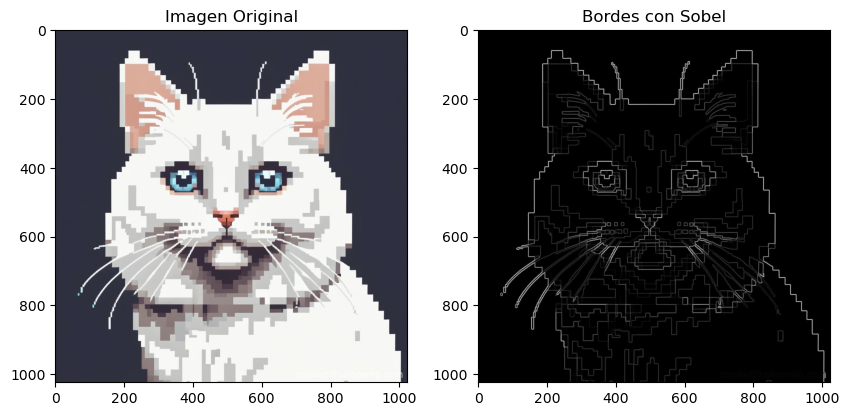

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_sobel_mejorado(img,kernel_size=3,umbral=30):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    #para mejorar la deteccion de filtro graus
    img_gris = cv2.GaussianBlur(img_gris, (3,3), 0)
    
    g_x=cv2.Sobel(img_gris, cv2.CV_64F, 1, 0, ksize=3)
    g_y=cv2.Sobel(img_gris, cv2.CV_64F, 0, 1, ksize=3)
    
    #ag=np.sqrt(np.square(g_x) + np.square(g_y))
    mag=np.sqrt(g_x**2 + g_y**2)
    mag=cv2.normalize(mag, None,0,255,cv2.NORM_MINMAX,cv2.CV_8U)
    _,bordes=cv2.threshold(mag,umbral,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    
    #OPERACION MORFOLOGICA PARA UNIR LOS BORDES ROTOS
    kernel_m=np.ones((2,2),np.uint8)
    bordes=cv2.morphologyEx(bordes, cv2.MORPH_CLOSE, kernel_m)
    return mag

#mostrar imagen
img=cv2.imread('imagen1.jpg')
sobel_result=filtro_sobel(img)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.title('Imagen Original')

plt.subplot(1,2,2)
plt.imshow(sobel_result,cmap='gray')
plt.title('Bordes con Sobel')
plt.show()


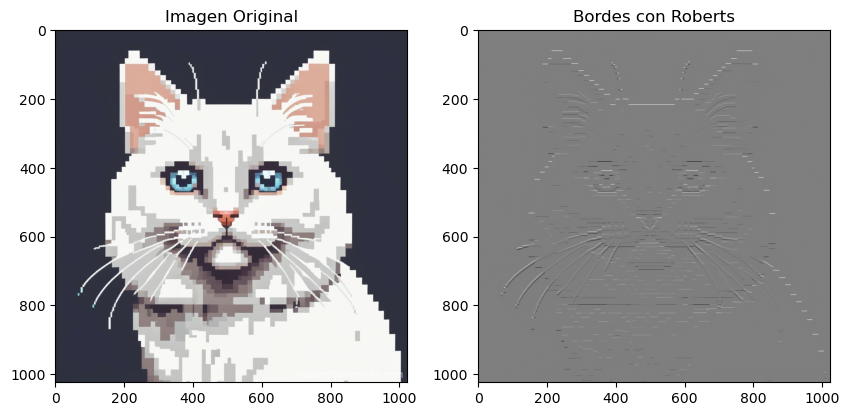

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_roberts(img):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    robertx_x=np.array([[-1,0], [0,1]], dtype=np.float32)
    roberty_y=np.array([[0,-1], [1,0]], dtype=np.float32)
    
    r_x=cv2.filter2D(img_gris, cv2.CV_64F, robertx_x)
    r_y=cv2.filter2D(img_gris, cv2.CV_64F, roberty_y)
    
    roberts=cv2.addWeighted(r_x, 0.5, r_y, 0.5, 0)

    return roberts

#mostrar imagen
img=cv2.imread('imagen1.jpg')
roberts_result=filtro_roberts(img)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.title('Imagen Original')
plt.subplot(1,2,2)
plt.imshow(roberts_result,cmap='gray')
plt.title('Bordes con Roberts')
plt.show()


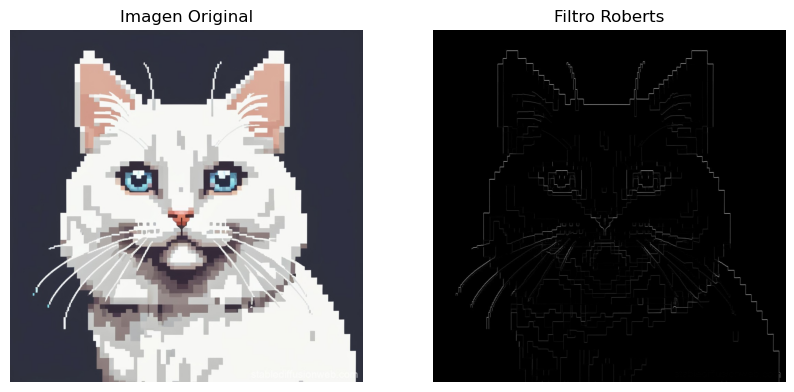

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_roberts(img):
    img_gris=cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    robertx=np.array([[-1,0],[0,1]],dtype=np.float32)
    roberty=np.array([[0,-1],[1,0]],dtype=np.float32)
    r_x=cv2.filter2D(img_gris,-1,robertx)
    r_y=cv2.filter2D(img_gris,-1,roberty)
    roberts=cv2.addWeighted(r_x,0.5,r_y,0.5,0)
    return roberts

img=cv2.imread('imagen1.jpg')
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.title('Imagen Original')
plt.axis('off')
roberts_result=filtro_roberts(img)
plt.subplot(1,2,2)
plt.imshow(roberts_result,cmap='gray')
plt.title('Filtro Roberts'), plt.axis('off')
plt.show()